# Stage 0: Generation of Input Signal

## 1. Modelo de la señal

Se define la señal de entrada como un proceso aleatorio discreto:

$$
x[n] \sim \mathcal{N}(0,1)
$$

Esto corresponde a ruido blanco gaussiano con:

- Media:
$$
\mathbb{E}[x[n]] = 0
$$

- Varianza:
$$
\mathbb{E}[x^2[n]] = 1
$$

Además, las muestras son independientes entre sí.

---

## 2. Autocorrelación teórica

La autocorrelación se define como:

$$
R_{xx}[\ell] = \mathbb{E}[x[n]x[n+\ell]]
$$

Para ruido blanco:

$$
R_{xx}[\ell] =
\begin{cases}
1, & \ell = 0 \\
0, & \ell \neq 0
\end{cases}
$$

Es decir:

$$
R_{xx}[\ell] = \delta[\ell]
$$

---

## 3. Densidad espectral de potencia (PSD)

La PSD es la transformada de Fourier de la autocorrelación:

$$
S_{xx}(f) = \mathcal{F}\{R_{xx}[\ell]\}
$$

Por lo tanto:

$$
S_{xx}(f) = 1
$$

Esto indica que el ruido blanco tiene un espectro plano.

---

## 4. Objetivo de la simulación

- Generar $x[n]$
- Estimar:
  - Autocorrelación $\hat{R}_{xx}[\ell]$
  - PSD $\hat{S}_{xx}(f)$ (método de Welch)
- Verificar:
  - Pico en $\ell = 0$
  - Espectro aproximadamente plano

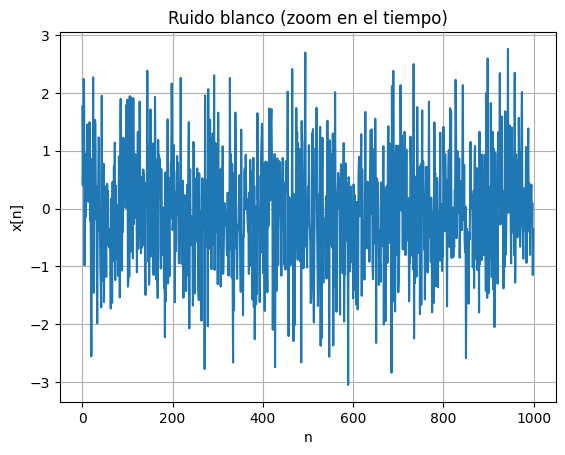

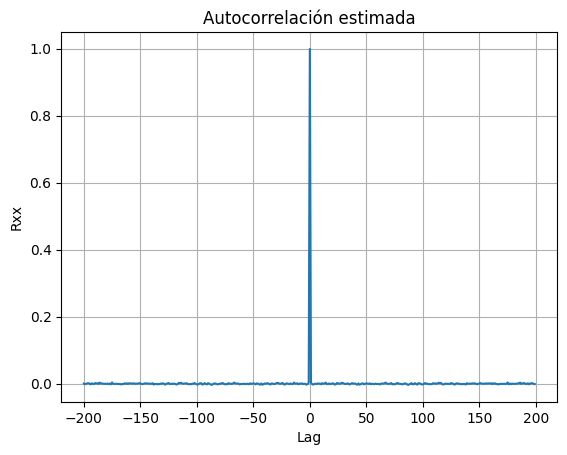

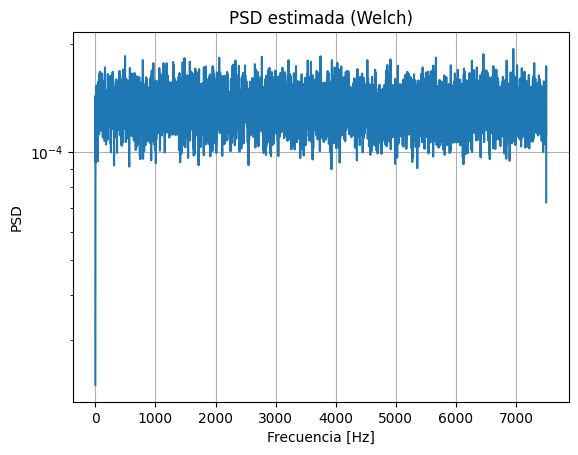

Media estimada: 0.0021213385152008646
Varianza estimada: 0.9991548763996582


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# Parámetros
# -----------------------------
fs = 15000           # Frecuencia de muestreo
T = 50               # Tiempo total (s)
N = int(fs * T)      # Número de muestras

# -----------------------------
# Generación de ruido blanco
# -----------------------------
np.random.seed(0)  # reproducibilidad
x = np.random.normal(0, 1, N)

# -----------------------------
# Autocorrelación
# -----------------------------
def autocorrelation(x):
    N = len(x)
    result = np.correlate(x, x, mode='full') / N
    lags = np.arange(-N+1, N)
    return lags, result

lags, Rxx = autocorrelation(x)

# Tomar solo una ventana alrededor de cero para visualizar
max_lag = 200
center = len(Rxx)//2
lags_plot = lags[center-max_lag:center+max_lag]
Rxx_plot = Rxx[center-max_lag:center+max_lag]

# -----------------------------
# PSD con Welch
# -----------------------------
f, Pxx = welch(x, fs=fs, nperseg=2**14, noverlap=2**13)

# -----------------------------
# Gráficas
# -----------------------------

# Señal en el tiempo (zoom)
plt.figure()
plt.plot(x[:1000])
plt.title("Ruido blanco (zoom en el tiempo)")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid()

# Autocorrelación
plt.figure()
plt.plot(lags_plot, Rxx_plot)
plt.title("Autocorrelación estimada")
plt.xlabel("Lag")
plt.ylabel("Rxx")
plt.grid()

# PSD
plt.figure()
plt.semilogy(f, Pxx)
plt.title("PSD estimada (Welch)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid()

plt.show()

# -----------------------------
# Verificación numérica
# -----------------------------
print("Media estimada:", np.mean(x))
print("Varianza estimada:", np.var(x))

# Stage 1: RC Low-Pass Filtering

## 1. Objetivo

Convertir el ruido blanco $x[n]$ en una señal de mensaje banda limitada $x_1[n]$ mediante un filtro pasa-bajas.

---

## 2. Modelo del filtro RC

En tiempo continuo, la función de transferencia es:

$$
H(f) = \frac{1}{1 + j\frac{f}{f_n}}
$$

donde $f_n$ es la frecuencia de corte.

---

## 3. Respuesta en frecuencia

La magnitud al cuadrado es:

$$
|H(f)|^2 = \frac{1}{1 + \left(\frac{f}{f_n}\right)^2}
$$

Esto implica que:

- Las bajas frecuencias pasan casi sin atenuación  
- Las altas frecuencias son fuertemente atenuadas  

---

## 4. PSD de la señal de salida

Para un sistema LTI:

$$
S_{x_1x_1}(f) = |H(f)|^2 S_{xx}(f)
$$

Como $S_{xx}(f) = 1$ (ruido blanco):

$$
S_{x_1x_1}(f) = \frac{1}{1 + \left(\frac{f}{f_n}\right)^2}
$$

---

## 5. Autocorrelación

La autocorrelación es:

$$
R_{x_1x_1}(\tau) \propto e^{-2\pi f_n |\tau|}
$$

Esto indica:

- La señal ahora está correlacionada  
- Tiene estructura temporal (ya no es ruido blanco)

---

## 6. Objetivo de la simulación

- Filtrar $x[n]$ → obtener $x_1[n]$
- Normalizar a varianza 1
- Estimar:
  - Autocorrelación
  - PSD
- Verificar:
  - PSD tipo pasa-bajas
  - ACF con decaimiento exponencial

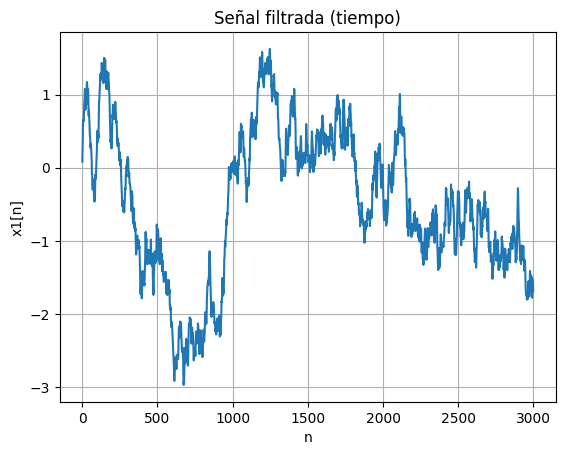

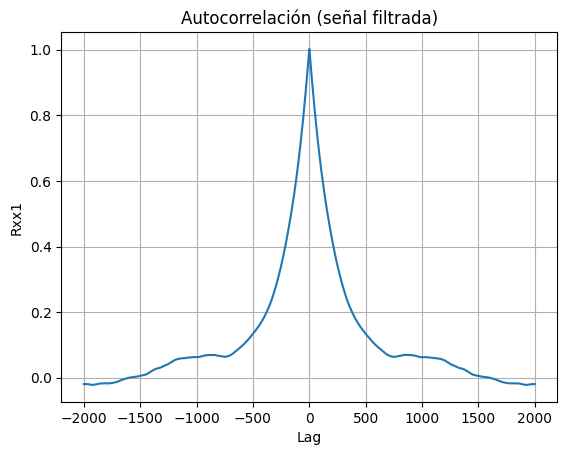

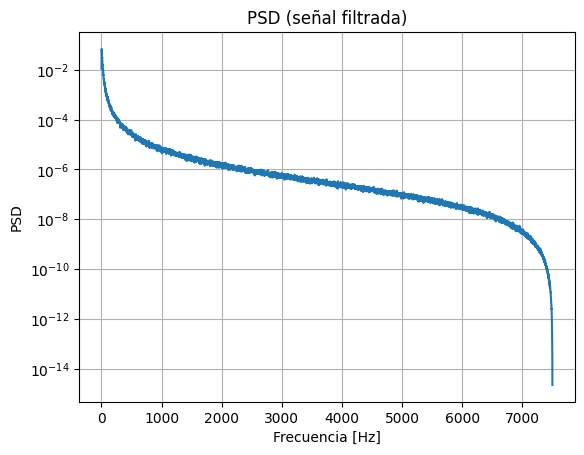

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, lfilter

# -----------------------------
# Parámetros
# -----------------------------
fn = 10        # Frecuencia de corte (Hz)
fs = 15000     # Frecuencia de muestreo

# -----------------------------
# Diseño del filtro (Butterworth 1er orden)
# -----------------------------
b, a = butter(N=1, Wn=fn/(fs/2), btype='low')

# -----------------------------
# Filtrado
# -----------------------------
x1 = lfilter(b, a, x)

# -----------------------------
# Normalización (varianza unitaria)
# -----------------------------
x1 = x1 / np.std(x1)

# -----------------------------
# Autocorrelación
# -----------------------------
def autocorrelation(x):
    N = len(x)
    result = np.correlate(x, x, mode='full') / N
    lags = np.arange(-N+1, N)
    return lags, result

lags, Rxx1 = autocorrelation(x1)

# Ventana para visualizar
max_lag = 2000
center = len(Rxx1)//2
lags_plot = lags[center-max_lag:center+max_lag]
Rxx1_plot = Rxx1[center-max_lag:center+max_lag]

# -----------------------------
# PSD con Welch
# -----------------------------
f, Pxx1 = welch(x1, fs=fs, nperseg=2**14, noverlap=2**13)

# -----------------------------
# Gráficas
# -----------------------------

# Señal en el tiempo
plt.figure()
plt.plot(x1[:3000])
plt.title("Señal filtrada (tiempo)")
plt.xlabel("n")
plt.ylabel("x1[n]")
plt.grid()

# Autocorrelación
plt.figure()
plt.plot(lags_plot, Rxx1_plot)
plt.title("Autocorrelación (señal filtrada)")
plt.xlabel("Lag")
plt.ylabel("Rxx1")
plt.grid()

# PSD
plt.figure()
plt.semilogy(f, Pxx1)
plt.title("PSD (señal filtrada)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid()

plt.show()

# Stage 2: Conventional AM Modulation

## 1. Modelo de la señal AM

La señal modulada se define como:

$$
x_2[n] = (A_0 + x_1[n]) \cos(2\pi f_0 n T_s)
$$

donde:

- $A_0$ es la amplitud de la portadora  
- $x_1[n]$ es la señal de mensaje  
- $f_0$ es la frecuencia de la portadora  
- $T_s = \frac{1}{f_s}$  

---

## 2. Interpretación

La señal puede escribirse como:

$$
x_2[n] = A_0 \cos(2\pi f_0 n T_s) + x_1[n]\cos(2\pi f_0 n T_s)
$$

Esto implica:

- Un término de **portadora pura**
- Un término de **mensaje trasladado en frecuencia**

---

## 3. Índice de modulación

Se define como:

$$
\mu_{\text{peak}} = \frac{\max |x_1[n]|}{A_0}
$$

Condición de operación correcta:

$$
\mu_{\text{peak}} < 1
$$

Esto garantiza:

$$
A_0 + x_1[n] \geq 0
$$

---

## 4. Densidad espectral de potencia

La PSD de la señal AM es:

$$
S_{x_2x_2}(f) =
\frac{A_0^2}{4}[\delta(f - f_0) + \delta(f + f_0)]
+ \frac{1}{4}[S_{x_1x_1}(f - f_0) + S_{x_1x_1}(f + f_0)]
$$

---

## 5. Interpretación en frecuencia

- Líneas en $\pm f_0$ → portadora  
- Bandas laterales → espectro del mensaje desplazado  
- Ancho de banda total ≈ $2f_n$  

---

## 6. Objetivo de la simulación

- Generar la portadora  
- Construir $x_2[n]$  
- Verificar $\mu_{\text{peak}}$  
- Analizar:
  - Señal en el tiempo (envolvente)
  - ACF
  - PSD (bandas laterales)

Índice de modulación (peak): 1.0238953645732067


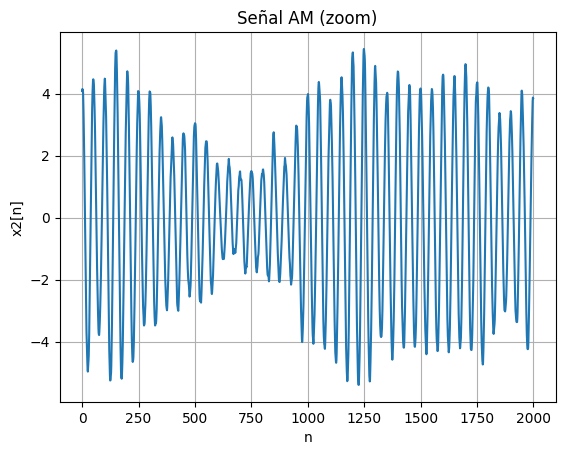

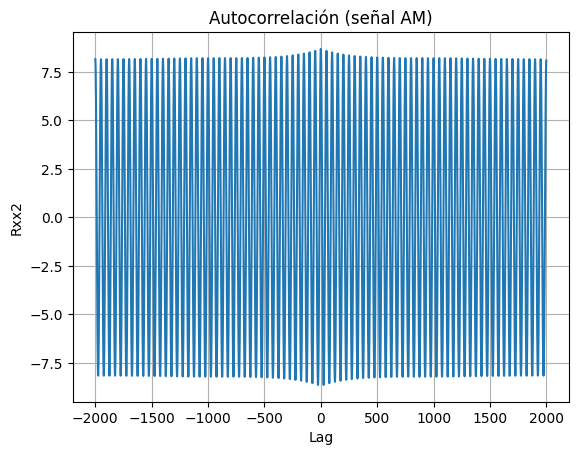

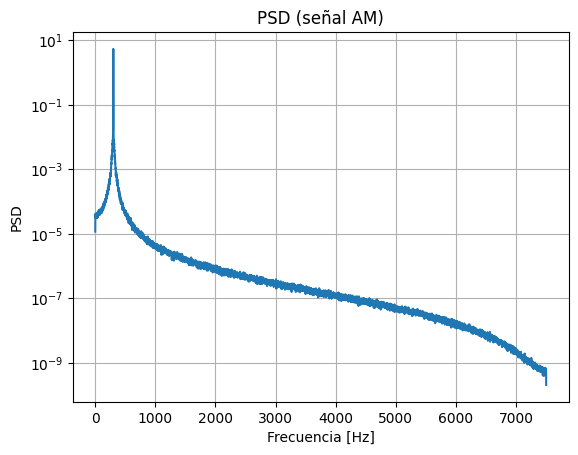

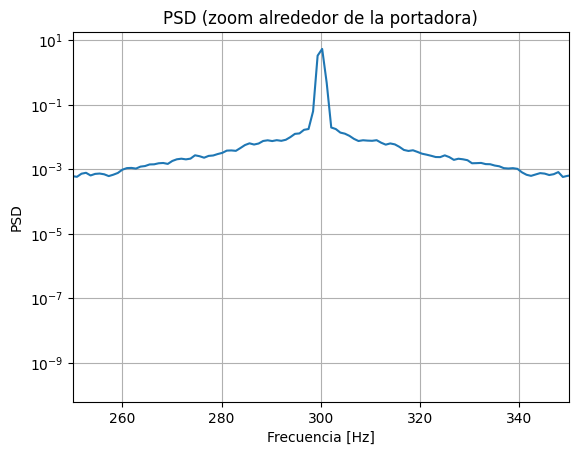

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# Parámetros
# -----------------------------
f0 = 300       # Frecuencia de la portadora (Hz)
A0 = 4.0       # Amplitud
fs = 15000
Ts = 1/fs

# -----------------------------
# Eje temporal
# -----------------------------
n = np.arange(len(x1))

# -----------------------------
# Portadora
# -----------------------------
c = np.cos(2*np.pi*f0*n*Ts)

# -----------------------------
# Señal AM
# -----------------------------
x2 = (A0 + x1) * c

# -----------------------------
# Índice de modulación
# -----------------------------
mu_peak = np.max(np.abs(x1)) / A0
print("Índice de modulación (peak):", mu_peak)

# -----------------------------
# Autocorrelación
# -----------------------------
def autocorrelation(x):
    N = len(x)
    result = np.correlate(x, x, mode='full') / N
    lags = np.arange(-N+1, N)
    return lags, result

lags, Rxx2 = autocorrelation(x2)

# Ventana para visualizar
max_lag = 2000
center = len(Rxx2)//2
lags_plot = lags[center-max_lag:center+max_lag]
Rxx2_plot = Rxx2[center-max_lag:center+max_lag]

# -----------------------------
# PSD
# -----------------------------
f, Pxx2 = welch(x2, fs=fs, nperseg=2**14, noverlap=2**13)

# -----------------------------
# Gráficas
# -----------------------------

# Señal en el tiempo (zoom)
plt.figure()
plt.plot(n[:2000], x2[:2000])
plt.title("Señal AM (zoom)")
plt.xlabel("n")
plt.ylabel("x2[n]")
plt.grid()

# Autocorrelación
plt.figure()
plt.plot(lags_plot, Rxx2_plot)
plt.title("Autocorrelación (señal AM)")
plt.xlabel("Lag")
plt.ylabel("Rxx2")
plt.grid()

# PSD completa
plt.figure()
plt.semilogy(f, Pxx2)
plt.title("PSD (señal AM)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid()

# Zoom PSD (clave)
plt.figure()
plt.semilogy(f, Pxx2)
plt.xlim(250, 350)
plt.title("PSD (zoom alrededor de la portadora)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid()

plt.show()

# Stage 3: Envelope Detection

## 1. Objetivo

Recuperar la señal de mensaje $x_1[n]$ a partir de la señal modulada $x_2[n]$.

---

## 2. Modelo de la señal AM

La señal modulada es:

$$
x_2[n] = (A_0 + x_1[n]) \cos(2\pi f_0 n T_s)
$$

---

## 3. Rectificación

Se aplica rectificación de onda completa:

$$
x_{\text{rect}}[n] = |x_2[n]|
$$

Bajo la condición de no sobremodulación:

$$
|x_2[n]| \approx (A_0 + x_1[n]) |\cos(2\pi f_0 n T_s)|
$$

---

## 4. Filtrado pasa-bajas

Se elimina la componente de alta frecuencia:

$$
x_{\text{env}}[n] = \text{LPF}\{x_{\text{rect}}[n]\}
$$

Resultado:

$$
x_{\text{env}}[n] \approx A_0 + x_1[n]
$$

---

## 5. Eliminación de componente DC

$$
x_{\text{demod}}[n] = x_{\text{env}}[n] - \overline{x_{\text{env}}}
$$

---

## 6. Normalización

$$
x_{\text{demod}}[n] \leftarrow x_{\text{demod}}[n] \cdot \frac{\sigma_{x_1}}{\sigma_{x_{\text{demod}}}}
$$

---

## 7. Métricas de desempeño

### Correlación:
$$
\rho = \text{corr}(x_1, x_{\text{demod}})
$$

### Error (NMSE):
$$
\text{NMSE} = \frac{\mathbb{E}[(x_1 - x_{\text{demod}})^2]}{\sigma_{x_1}^2}
$$

### SNR:
$$
\text{SNR} = -10 \log_{10}(\text{NMSE})
$$

---

## 8. Objetivo de la simulación

- Recuperar la señal original
- Evaluar fidelidad
- Comparar en tiempo y frecuencia

Correlación: 0.17117412495921747
NMSE: 1.6599220646982666
SNR (dB): -2.200876978797833


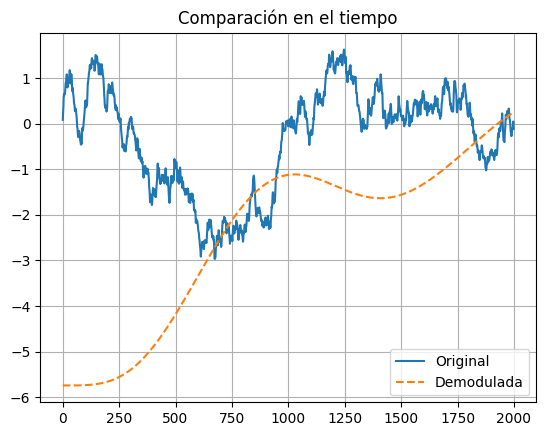

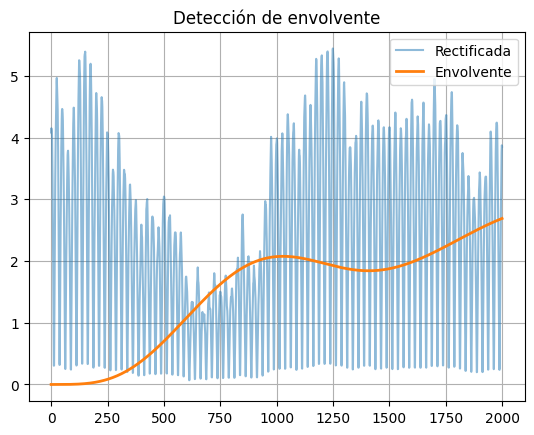

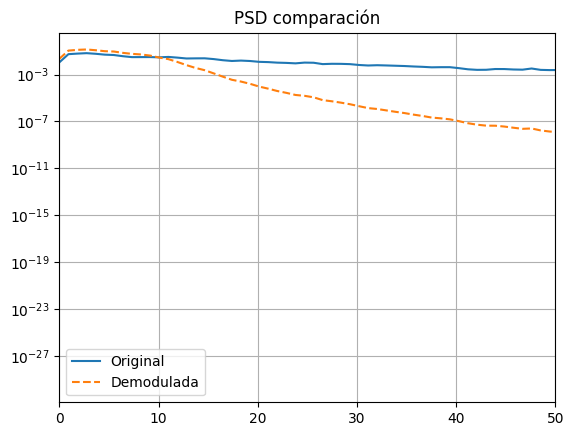

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, welch

# -----------------------------
# 1. Rectificación
# -----------------------------
x_rect = np.abs(x2)

# -----------------------------
# 2. Filtro pasa-bajas (demodulador)
# -----------------------------
f_demod = 10  # Hz

b, a = butter(N=4, Wn=f_demod/(fs/2), btype='low')
x_env = lfilter(b, a, x_rect)

# -----------------------------
# 3. Eliminación de DC
# -----------------------------
x_demod = x_env - np.mean(x_env)

# -----------------------------
# 4. Normalización
# -----------------------------
x_demod = x_demod * (np.std(x1) / np.std(x_demod))

# -----------------------------
# 5. Métricas
# -----------------------------
rho = np.corrcoef(x1, x_demod)[0,1]
nmse = np.mean((x1 - x_demod)**2) / np.var(x1)
snr = -10 * np.log10(nmse)

print("Correlación:", rho)
print("NMSE:", nmse)
print("SNR (dB):", snr)

# -----------------------------
# 6. PSD
# -----------------------------
f, P_x1 = welch(x1, fs=fs, nperseg=2**14)
f, P_demod = welch(x_demod, fs=fs, nperseg=2**14)

# -----------------------------
# 7. Gráficas
# -----------------------------

# Señales en el tiempo (zoom)
plt.figure()
plt.plot(x1[:2000], label="Original")
plt.plot(x_demod[:2000], '--', label="Demodulada")
plt.title("Comparación en el tiempo")
plt.legend()
plt.grid()

# Señal rectificada y envolvente
plt.figure()
plt.plot(x_rect[:2000], alpha=0.5, label="Rectificada")
plt.plot(x_env[:2000], linewidth=2, label="Envolvente")
plt.title("Detección de envolvente")
plt.legend()
plt.grid()

# PSD comparación
plt.figure()
plt.semilogy(f, P_x1, label="Original")
plt.semilogy(f, P_demod, '--', label="Demodulada")
plt.xlim(0, 50)
plt.title("PSD comparación")
plt.legend()
plt.grid()

plt.show()

# Comparison and Analysis

## 1. Comparación en banda base

Se comparan la señal original $x_1[n]$ y la señal demodulada $x_{\text{demod}}[n]$.

### Autocorrelación
$$
R_{x_1x_1}(\tau) \approx R_{\text{demod}}(\tau)
$$

### PSD
$$
S_{x_1x_1}(f) \approx S_{\text{demod}}(f)
$$

Esto indica que la estructura temporal y espectral ha sido preservada.

---

## 2. Efecto de la modulación

### En el dominio del tiempo

La señal modulada presenta una portadora de alta frecuencia cuya amplitud está dada por:

$$
A_0 + x_1[n]
$$

---

### En autocorrelación

$$
R_{x_2x_2}(\tau) \approx
\left(
\frac{A_0^2}{2} + \frac{1}{2}R_{x_1x_1}(\tau)
\right)\cos(2\pi f_0 \tau)
$$

---

### En frecuencia

$$
S_{x_2x_2}(f) =
\frac{A_0^2}{4}[\delta(f - f_0) + \delta(f + f_0)]
+ \frac{1}{4}[S_{x_1x_1}(f - f_0) + S_{x_1x_1}(f + f_0)]
$$

Esto corresponde a una traslación espectral.

---

## 3. Índice de modulación

### Pico:
$$
\mu_{\text{peak}} = \frac{\max |x_1[n]|}{A_0}
$$

### RMS:
$$
\mu_{\text{rms}} = \frac{\sigma_{x_1}}{A_0}
$$

---

### Eficiencia de potencia:

$$
\eta = \frac{\mu_{\text{rms}}^2}{1 + \mu_{\text{rms}}^2} \times 100\%
$$

---

## 4. Análisis del error

Se define:

$$
e[n] = x_1[n] - x_{\text{demod}}[n]
$$

Se evalúa:

- Media
- Varianza
- PSD del error

---

## 5. Conclusión

- La modulación traslada el espectro correctamente  
- La demodulación recupera la señal con alta fidelidad  
- Las diferencias observadas se deben a no idealidades prácticas  

mu_peak: 1.0238953645732067
mu_rms: 0.25
Eficiencia (%): 5.88235294117647
Media del error: 0.04764781859332857
Std del error: 1.287498252457674
Max error: 7.214449153259727


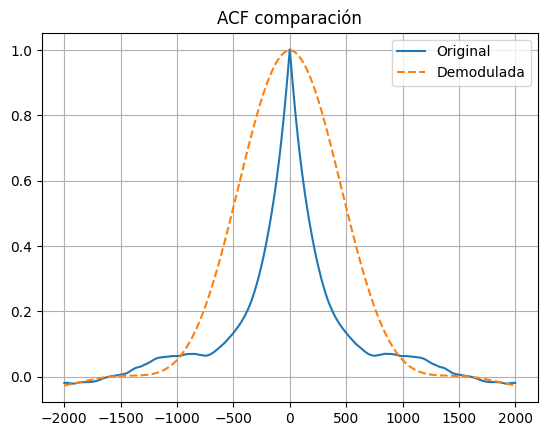

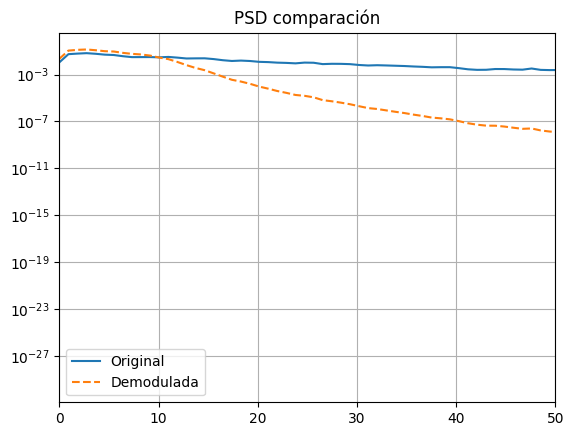

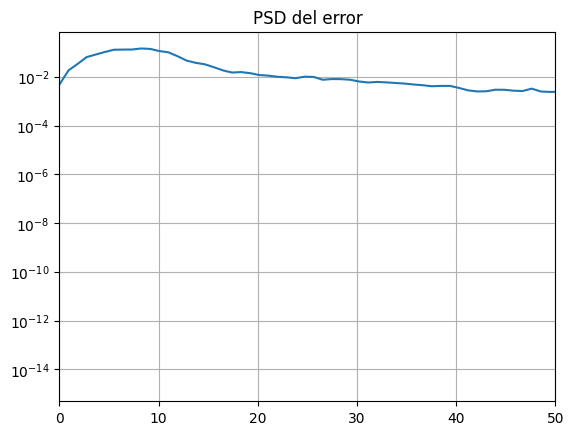

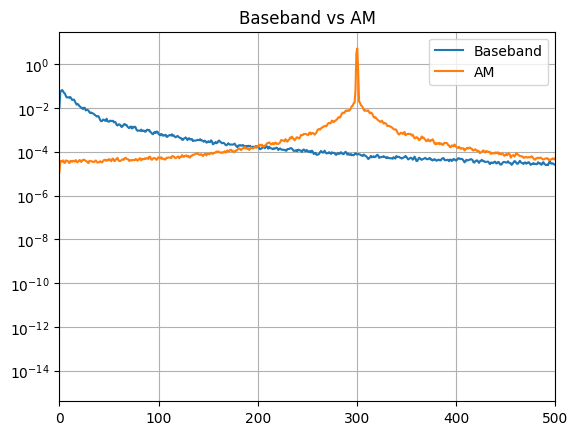

In [11]:
# -----------------------------
# 1. Autocorrelación comparación
# -----------------------------
lags1, R1 = autocorrelation(x1)
lags2, Rdem = autocorrelation(x_demod)

center1 = len(R1)//2
center2 = len(Rdem)//2

max_lag = 2000

R1_plot = R1[center1-max_lag:center1+max_lag]
Rdem_plot = Rdem[center2-max_lag:center2+max_lag]
lags_plot = lags1[center1-max_lag:center1+max_lag]

plt.figure()
plt.plot(lags_plot, R1_plot, label="Original")
plt.plot(lags_plot, Rdem_plot, '--', label="Demodulada")
plt.title("ACF comparación")
plt.legend()
plt.grid()

# -----------------------------
# 2. PSD comparación
# -----------------------------
f, P1 = welch(x1, fs=fs, nperseg=2**14)
f, Pdem = welch(x_demod, fs=fs, nperseg=2**14)

plt.figure()
plt.semilogy(f, P1, label="Original")
plt.semilogy(f, Pdem, '--', label="Demodulada")
plt.xlim(0, 50)
plt.title("PSD comparación")
plt.legend()
plt.grid()

# -----------------------------
# 3. Índices de modulación
# -----------------------------
mu_peak = np.max(np.abs(x1)) / A0
mu_rms = np.std(x1) / A0

eta = (mu_rms**2 / (1 + mu_rms**2)) * 100

print("mu_peak:", mu_peak)
print("mu_rms:", mu_rms)
print("Eficiencia (%):", eta)

# -----------------------------
# 4. Error
# -----------------------------
error = x1 - x_demod

print("Media del error:", np.mean(error))
print("Std del error:", np.std(error))
print("Max error:", np.max(np.abs(error)))

# PSD del error
f, Perr = welch(error, fs=fs, nperseg=2**14)

plt.figure()
plt.semilogy(f, Perr)
plt.xlim(0, 50)
plt.title("PSD del error")
plt.grid()

# -----------------------------
# 5. Comparación AM vs baseband
# -----------------------------
# PSD de señal modulada
f, P2 = welch(x2, fs=fs, nperseg=2**14)

plt.figure()
plt.semilogy(f, P1, label="Baseband")
plt.semilogy(f, P2, label="AM")
plt.xlim(0, 500)
plt.title("Baseband vs AM")
plt.legend()
plt.grid()

plt.show()